#### Using Caffe Models for Inference

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
fileName = 'data/images/panda.jpg'
protoFile = 'data/models/bvlc_googlenet.prototxt'
weightFile = 'data/models/bvlc_googlenet.caffemodel'
classFile = 'data/models/classification_classes_ILSVRC2012.txt'

Class Id: 388
Predicted class: giant panda, panda, panda bear, coon bear, Ailuropoda melanoleuca, 
Confidence: 1.000


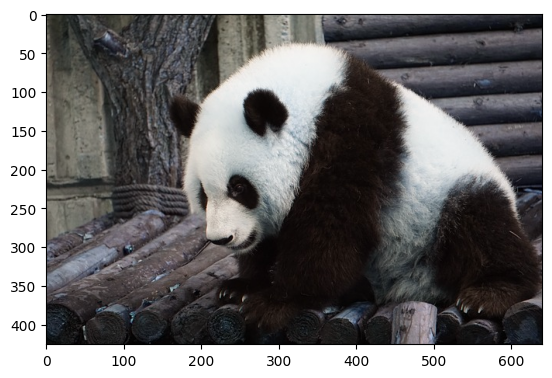

In [7]:
frame = cv2.imread(fileName)

classes = None

with open(classFile, 'r') as f:
    classes = f.read().rstrip().split('\n')

inHeight = 224
inWidth = 224
swap_rgb = False
mean = [104, 117, 123]
scale = 1.0

# Load a network
net = cv2.dnn.readNetFromCaffe(protoFile, weightFile)
# Create a 4D blob from a frame.
blob = cv2.dnn.blobFromImage(frame, scale, (inWidth, inHeight), mean, swap_rgb, crop=False)

# Run a model
net.setInput(blob)
out = net.forward()

# Get a class with a highest score.
out = out.flatten()
classId = np.argmax(out)

className = classes[classId]
confidence = out[classId]
label = f'Predicted class: {className}, \nConfidence: {confidence:.3f}'

plt.imshow(frame)
print(f'Class Id: {classId}')
print(label)

#### Using tensorflow model for Inference

Class Id: 169
Predicted class: giant panda, 
Confidence: 1.000


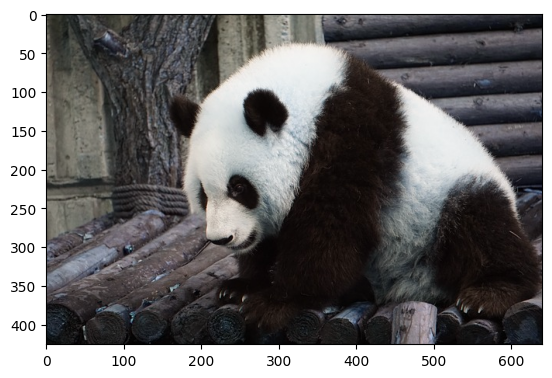

In [8]:
import cv2
import numpy as np

weightFile = 'data/models/tensorflow_inception_graph.pb'

frame = cv2.imread(fileName)

classFile = 'data/models/imagenet_comp_graph_label_strings.txt'
classes = None

with open(classFile, 'rt') as f:
    classes = f.read().rstrip('\n').split('\n')

inHeight = 224
inWidth = 224
swap_rgb = True
mean = [117, 117, 117]
scale = 1.0

# Load a network
net = cv2.dnn.readNetFromTensorflow(weightFile)
# Create a 4D blob from a frame.
blob = cv2.dnn.blobFromImage(frame, scale, (inWidth, inHeight), mean, swap_rgb, crop=False)

# Run a model
net.setInput(blob)
out = net.forward()

# Get a class with a highest score.
out = out.flatten()
classId = np.argmax(out)

className = classes[classId]
confidence = out[classId]

label = f'Predicted class: {className}, \nConfidence: {confidence:.3f}'

plt.imshow(frame)
print(f'Class Id: {classId}')
print(label)

#### Single Shot Multibox Detector (SSD)

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
modelFile = 'data/models/ssd_mobilenet_v2_coco_2018_03_29/frozen_inference_graph.pb'
configFile = 'data/models/ssd_mobilenet_v2_coco_2018_03_29.pbtxt'
classFile = 'data/models/coco_class_labels.txt'

In [15]:
# Load a network
net = cv2.dnn.readNetFromTensorflow(modelFile, configFile)

with open(classFile) as f:
    labels = f.read().split('\n')
print(labels, '\n', len(labels))

['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'hair brush', ''] 
 93


In [16]:
def detectObjects(net, im):
    dim = 300
    mean = (127.5, 127.5, 127.5)

    # Create the blob from the image
    blob = cv2.dnn.blobFromImage(im, 1.0/127.5, (dim, dim), mean, swapRB=True)

    # Pass blob to the network
    net.setInput(blob)

    #Perform Predictions
    objects = net.forward()
    return objects

In [27]:
def display_text(im, text, x, y):
    # Get text size
    textSize = cv2.getTextSize(text, FONTFACE, FONTSCALE, THICKNESS)
    dim = textSize[0]
    baseline = textSize[1]
    # Use text size to create a black rectangle
    cv2.rectangle(im, (x, y - dim[1] - baseline), (x + dim[0], y + baseline), (0,0,0), cv2.FILLED);
    # Display text inside the rectangle
    cv2.putText(im, text, (x, y - 5), FONTFACE, FONTSCALE, (0,255,255), THICKNESS, cv2.LINE_AA)


In [28]:
FONTFACE = cv2.FONT_HERSHEY_COMPLEX
FONTSCALE = 0.7
THICKNESS = 1

def display_objects(im, objects, threshold = 0.25):
    rows = im.shape[0]; cols = im.shape[1]

    # for every detected object
    for i in range(objects.shape[2]):
        # Find the class and confidence
        classId = int(objects[0, 0, i, 1])
        score = float(objects[0, 0, i, 2])
        
        # Recover original cordinates from normalized coordinates
        x = int(objects[0, 0, i, 3] * cols)
        y = int(objects[0, 0, i, 4] * rows)
        w = int(objects[0, 0, i, 5] * cols - x)
        h = int(objects[0, 0, i, 6] * rows - y)
        
        # Check if the detection is of good quality
        if score > threshold:
            display_text(im, "{}".format(labels[classId]), x, y)
            cv2.rectangle(im, (x, y), (x + w, y + h), (255, 255, 255), 2)
    
    # Convert Image to RGB since we are using Matplotlib for displaying image
    mp_img = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(30,10)); plt.imshow(mp_img); plt.show();

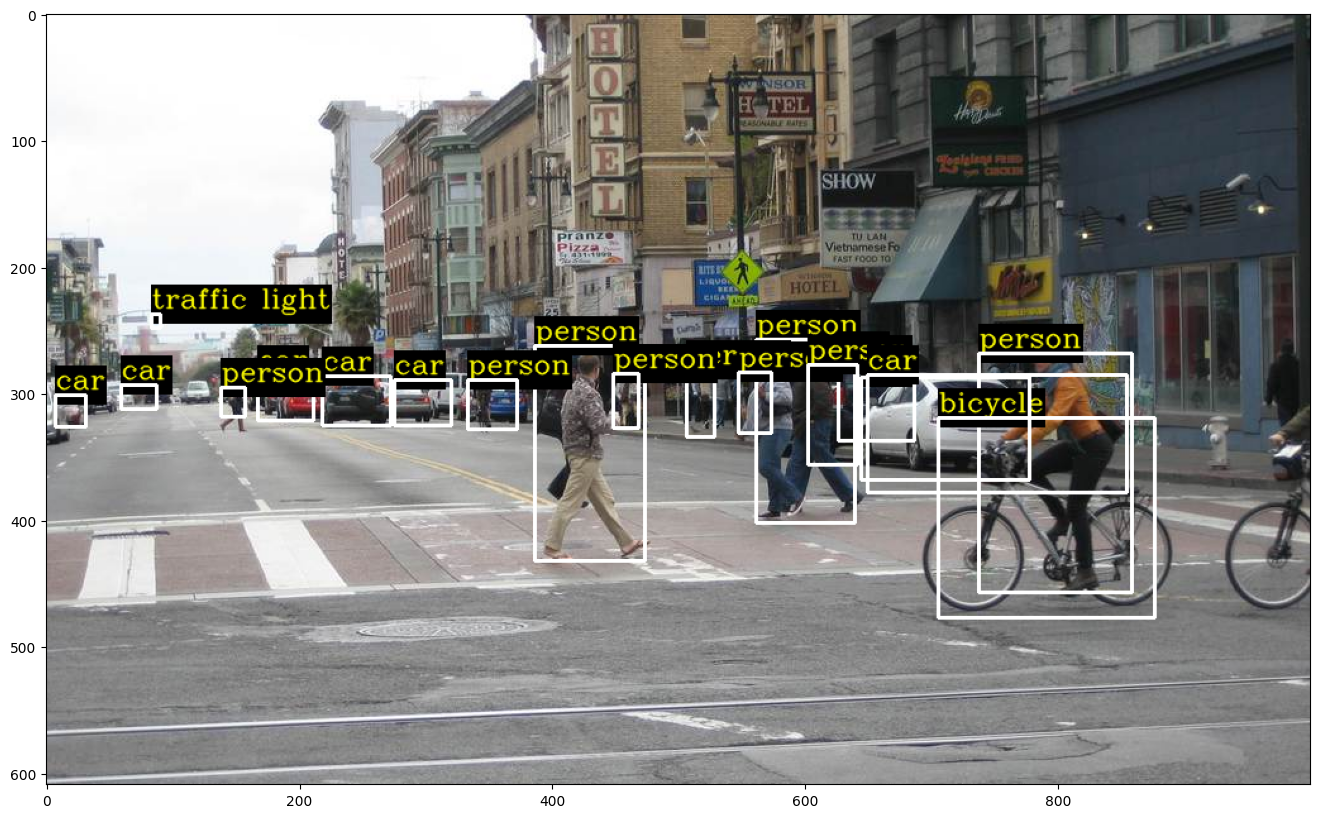

In [29]:
im = cv2.imread('data/images/street.jpg')
objects = detectObjects(net, im)
display_objects(im, objects)

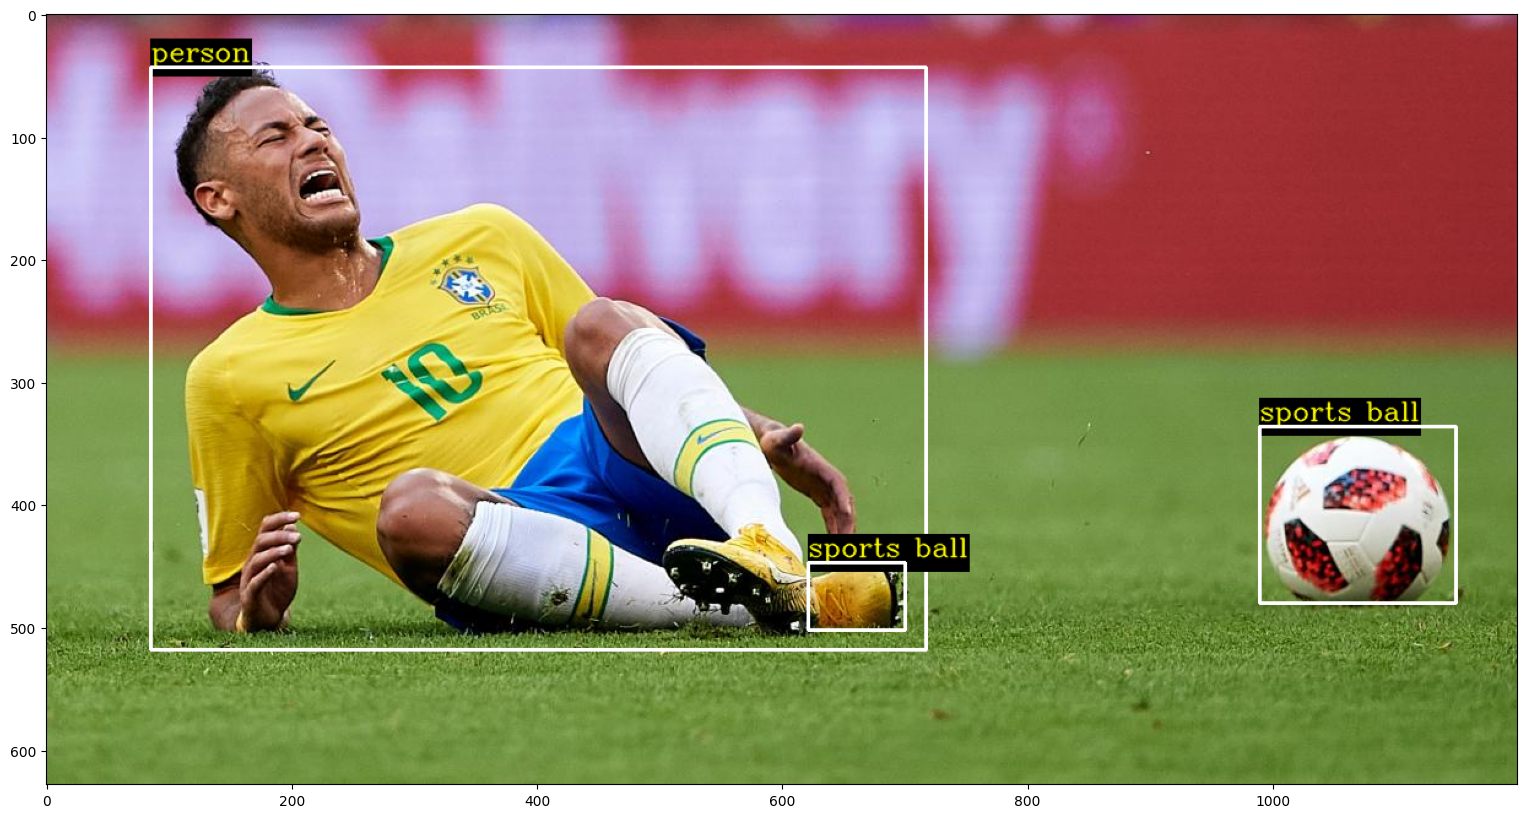

In [30]:
im = cv2.imread('data/images/soccer.jpg')
objects = detectObjects(net, im)
display_objects(im, objects)